# CS 486/686: Assignment 1

---
## 1. Shortest Route to Waterloo (20 points)

### Q1.1 [5 pts]

A heuristic h is consistent if h(n) <= c(n, n') + h(n') for every edge. By the Euclidean triangle inequality, h(n) <= eucl(n, n') + h(n'), where eucl(n, n') is the straight-line distance between n and n'. Since driving distance is always at least as long as straight-line distance, c(n, n') >= eucl(n, n'). Combining, h(n) <= eucl(n, n') + h(n') <= c(n, n') + h(n'), so the heuristic is consistent.

### Q1.2 [15 pts]

A* search tree from Toronto to Waterloo using Euclidean distance heuristic. No pruning. F-value ties broken alphabetically. Stops when goal (Wat) is expanded.

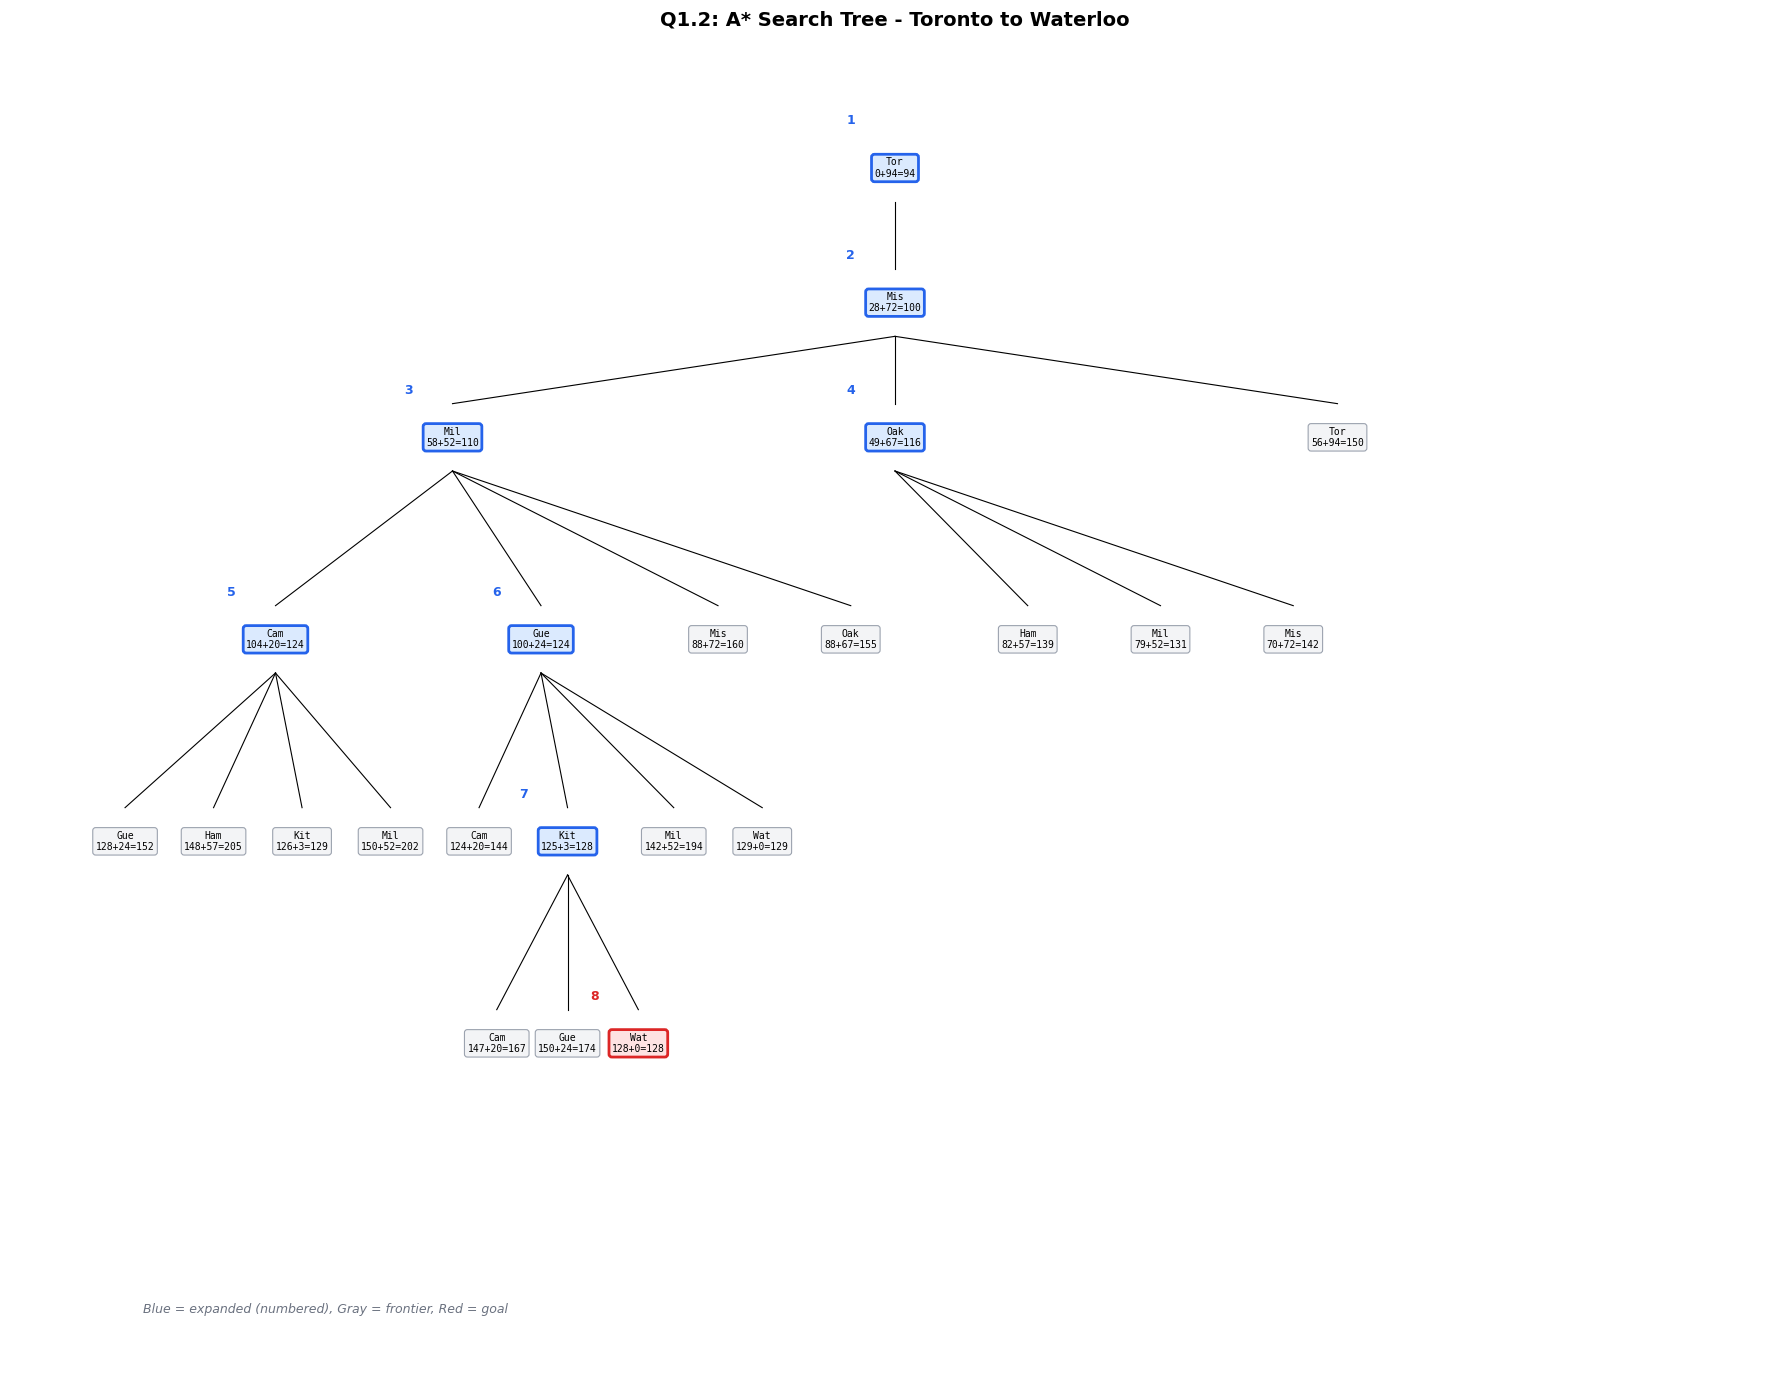

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(18, 14))
ax.set_xlim(-1, 19)
ax.set_ylim(-1, 9)
ax.invert_yaxis()
ax.axis('off')
ax.set_title('Q1.2: A* Search Tree - Toronto to Waterloo', fontsize=14, fontweight='bold')

nodes = [
    (9, 0, 'Tor', 0, 94, 94, 1),
    (9, 1, 'Mis', 28, 72, 100, 2),
    (4, 2, 'Mil', 58, 52, 110, 3),
    (9, 2, 'Oak', 49, 67, 116, 4),
    (14, 2, 'Tor', 56, 94, 150, None),
    (2, 3.5, 'Cam', 104, 20, 124, 5),
    (5, 3.5, 'Gue', 100, 24, 124, 6),
    (7, 3.5, 'Mis', 88, 72, 160, None),
    (8.5, 3.5, 'Oak', 88, 67, 155, None),
    (10.5, 3.5, 'Ham', 82, 57, 139, None),
    (12, 3.5, 'Mil', 79, 52, 131, None),
    (13.5, 3.5, 'Mis', 70, 72, 142, None),
    (0.3, 5, 'Gue', 128, 24, 152, None),
    (1.3, 5, 'Ham', 148, 57, 205, None),
    (2.3, 5, 'Kit', 126, 3, 129, None),
    (3.3, 5, 'Mil', 150, 52, 202, None),
    (4.3, 5, 'Cam', 124, 20, 144, None),
    (5.3, 5, 'Kit', 125, 3, 128, 7),
    (6.5, 5, 'Mil', 142, 52, 194, None),
    (7.5, 5, 'Wat', 129, 0, 129, None),
    (4.5, 6.5, 'Cam', 147, 20, 167, None),
    (5.3, 6.5, 'Gue', 150, 24, 174, None),
    (6.1, 6.5, 'Wat', 128, 0, 128, 8),
]

edges = [
    (0,1),(1,2),(1,3),(1,4),
    (2,5),(2,6),(2,7),(2,8),
    (3,9),(3,10),(3,11),
    (5,12),(5,13),(5,14),(5,15),
    (6,16),(6,17),(6,18),(6,19),
    (17,20),(17,21),(17,22),
]

for pi, ci in edges:
    px, py = nodes[pi][0], nodes[pi][1]
    cx, cy = nodes[ci][0], nodes[ci][1]
    ax.plot([px, cx], [py+0.25, cy-0.25], 'k-', linewidth=0.8, zorder=1)

for i, (x, y, label, c, h, f, exp) in enumerate(nodes):
    is_goal = (label == 'Wat' and exp == 8)
    color = '#fee2e2' if is_goal else ('#dbeafe' if exp else '#f3f4f6')
    ec = '#dc2626' if is_goal else ('#2563eb' if exp else '#9ca3af')
    lw = 2.0 if exp else 0.8
    bbox = dict(boxstyle='round,pad=0.3', facecolor=color, edgecolor=ec, linewidth=lw)
    ax.text(x, y, f'{label}\n{c}+{h}={f}', ha='center', va='center', fontsize=7, fontfamily='monospace', bbox=bbox, zorder=2)
    if exp:
        ax.text(x-0.5, y-0.35, str(exp), ha='center', va='center', fontsize=9, fontweight='bold', color='#2563eb' if not is_goal else '#dc2626', zorder=3)

ax.text(0.5, 8.5, 'Blue = expanded (numbered), Gray = frontier, Red = goal', fontsize=9, style='italic', color='#6b7280')
plt.tight_layout()
plt.show()


**Expansion order:**

| # | Node | C | H | F | Note |
|---|------|---|---|---|------|
| 1 | Tor | 0 | 94 | 94 | |
| 2 | Mis | 28 | 72 | 100 | |
| 3 | Mil | 58 | 52 | 110 | |
| 4 | Oak | 49 | 67 | 116 | |
| 5 | Cam | 104 | 20 | 124 | tie F=124: Cam before Gue alphabetically |
| 6 | Gue | 100 | 24 | 124 | |
| 7 | Kit | 125 | 3 | 128 | |
| 8 | Wat | 128 | 0 | 128 | goal expanded, search terminates |

Shortest path found: Tor -> Mis -> Mil -> Gue -> Kit -> Wat, total cost = 128 km.

---
## 2. Travelling Salesperson (30 points)

### Q2a [5 pts]

States: Each state is a pair (current_city, visited), where current_city is the city the salesperson is currently in, and visited is the set of cities already visited. For the small example, a state looks like (G, {W, B, G}), meaning the salesperson is in Guelph and has visited Waterloo, Barrie, and Guelph so far.

Initial state: (W, {W}) — the salesperson starts at Waterloo with only Waterloo marked as visited.

Goal state: Any state where current_city is the starting city and visited contains all cities. For the small example, the goal is (W, {W, B, G, H, T}).

Neighbour rules: From state (c, V):
- If V does not yet contain all cities: for each city c' not in V, generate (c', V ∪ {c'}) with cost equal to the distance from c to c'. Since the graph is complete, every unvisited city is reachable.
- If V contains all cities and c ≠ start: generate (start, V) with cost equal to the distance from c to start. This represents the return trip.

For example, from state (G, {W, B, G}), the neighbours are (H, {W, B, G, H}) with cost 49 and (T, {W, B, G, T}) with cost 99.

### Q2b [5 pts]

The cost of an edge is the distance between the two cities it connects. The total path cost g(n) for a state n is the sum of all edge costs along the path from the initial state to n.

For example, the path W -> G -> H has edge costs 36 (Waterloo to Guelph) and 49 (Guelph to Hamilton), so g = 36 + 49 = 85.

### Q2c [10 pts]

Heuristic: h(n) = cost of the minimum spanning tree (MST) over the set of cities that the remaining tour must connect. Specifically, for state (c, V), this set is {c} ∪ {all unvisited cities} ∪ {start}.

Example: Consider state n = (G, {W, G}), meaning the salesperson is at Guelph and has visited Waterloo and Guelph. The remaining tour must connect {G, B, H, T, W}. Sorting all edges and applying Kruskal's algorithm:

1. W-G (36) — add
2. G-H (49) — add
3. W-H (73) — skip (W, G, H already connected)
4. H-T (77) — add
5. G-T (99) — skip (G, H, T already connected)
6. B-T (107) — add (4 edges for 5 nodes, done)

MST cost = 36 + 49 + 77 + 107 = 269, so h(n) = 269.

Admissibility: The remaining tour visits all remaining cities and returns to start, forming a cycle through the cities in the set. Removing one edge from this cycle produces a spanning tree of those cities. Since MST has the minimum cost among all spanning trees, MST cost <= spanning tree cost <= cycle cost = actual remaining tour cost. Therefore h(n) never overestimates the true remaining cost, so it is admissible.

### Q2d [10 pts]

A* search tree for the small TSP example (W,B,G,H,T), using MST heuristic, 8 nodes expanded. Tie-break: smallest g, then alphabetical city sequence.

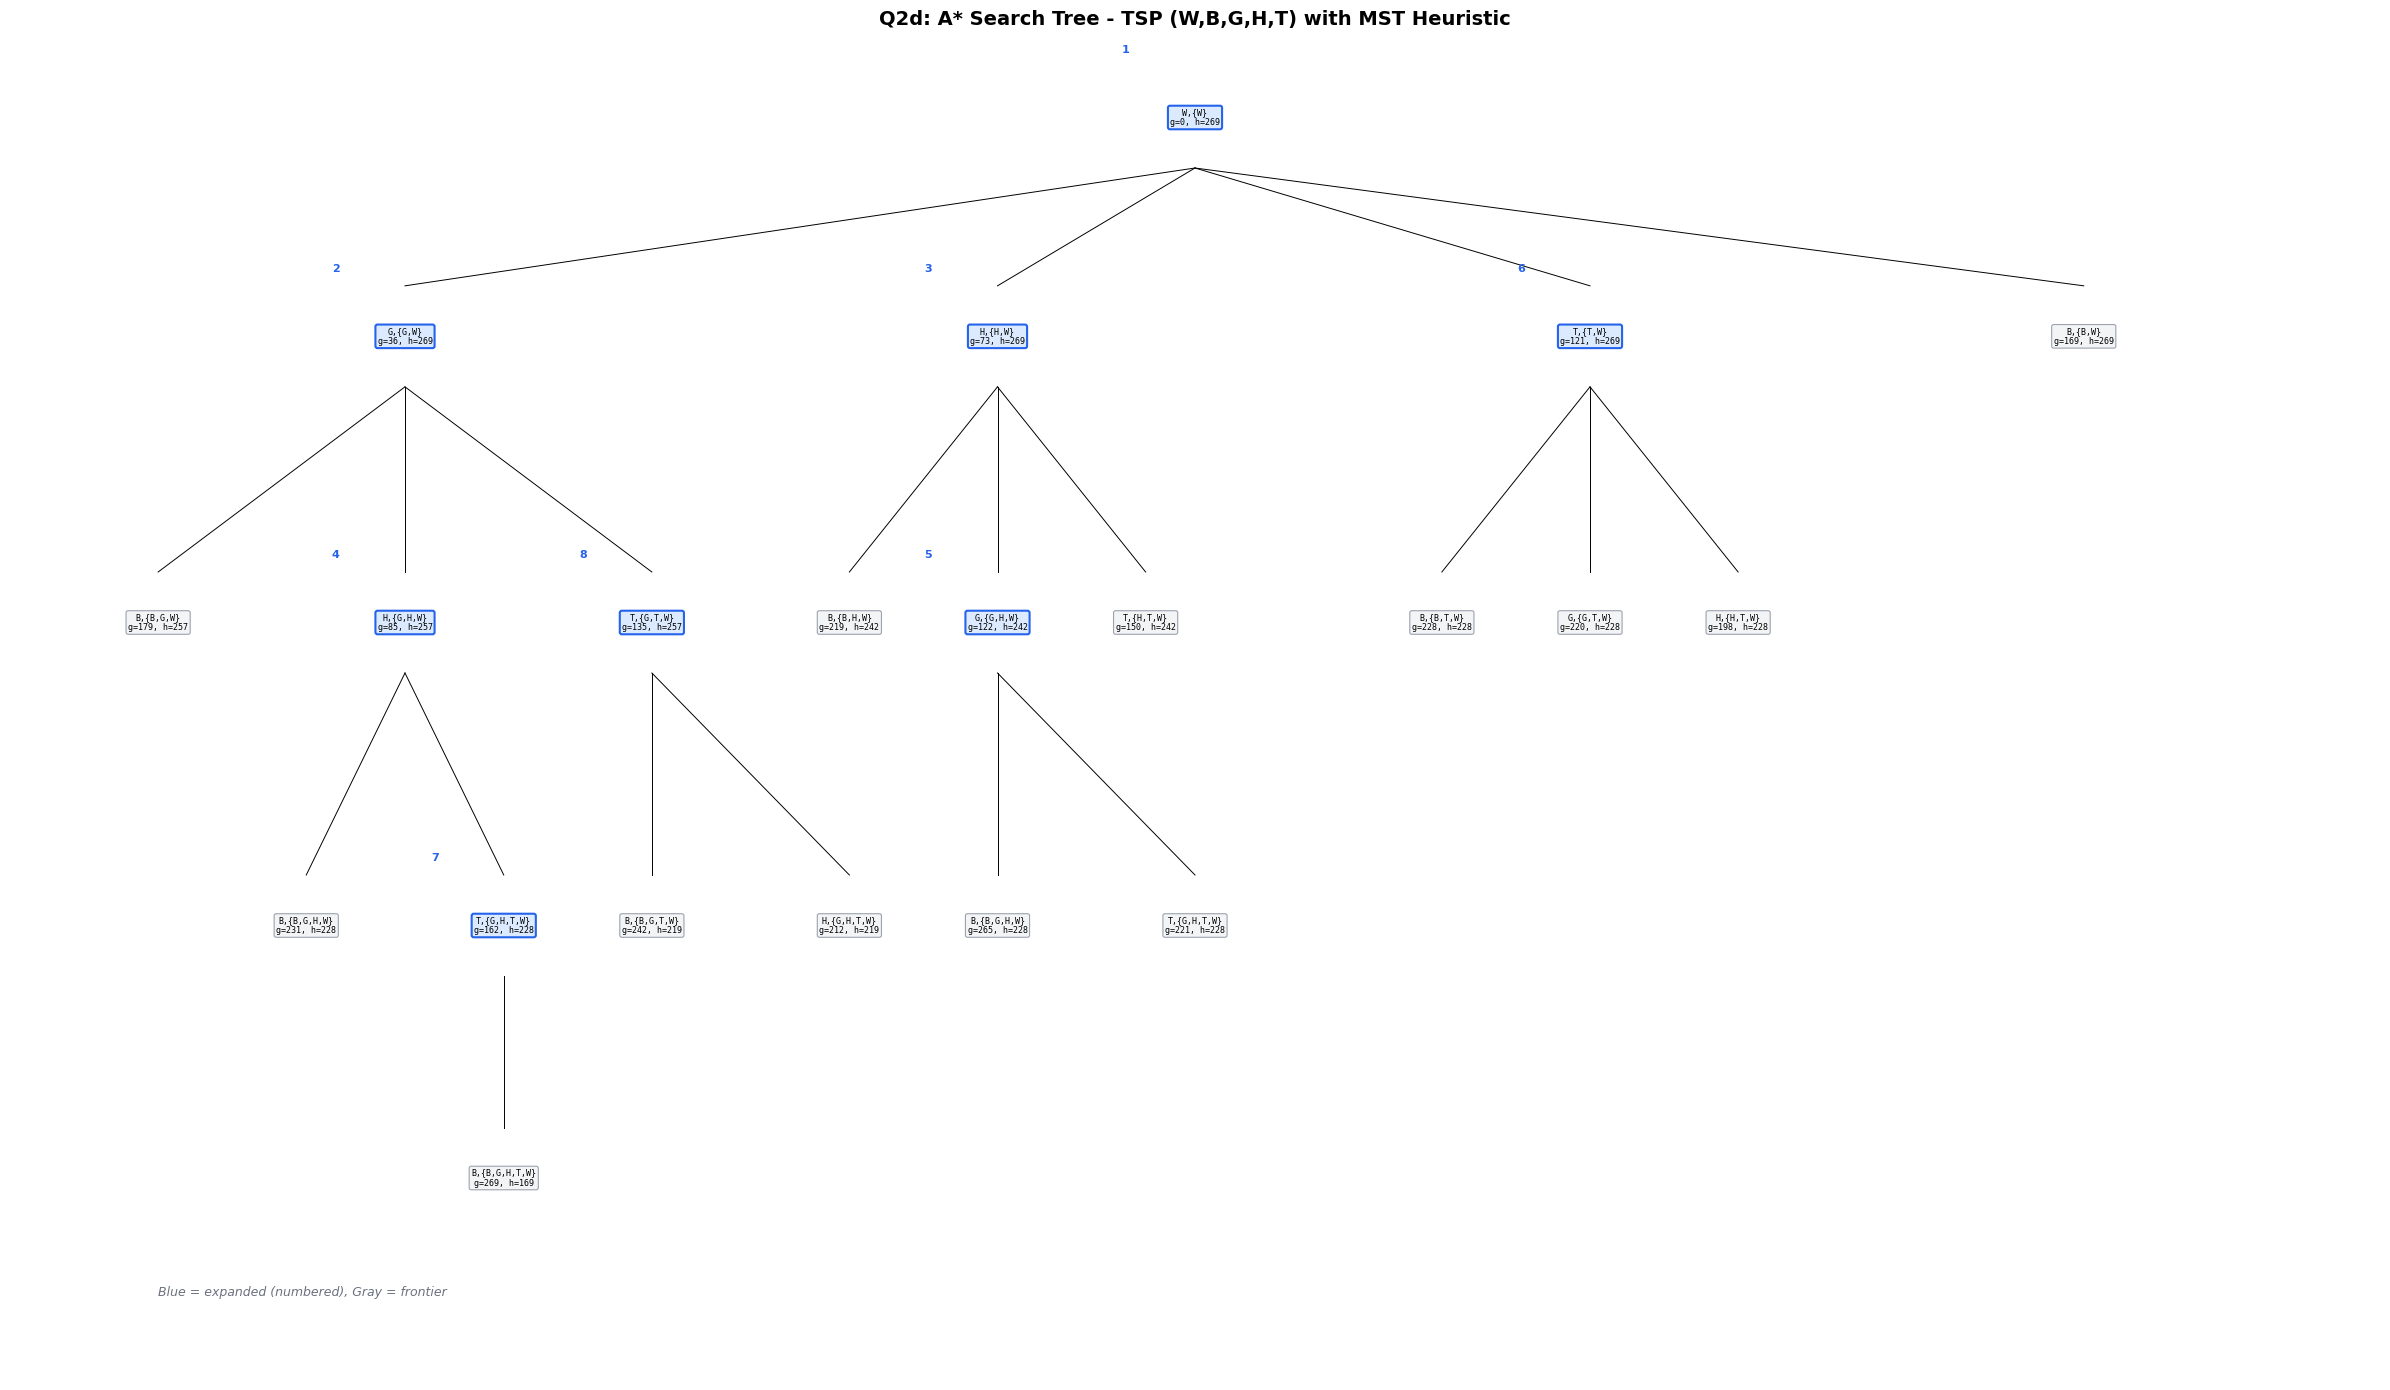

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(24, 14))
ax.set_xlim(-1, 23)
ax.set_ylim(-0.5, 7.5)
ax.invert_yaxis()
ax.axis('off')
ax.set_title('Q2d: A* Search Tree - TSP (W,B,G,H,T) with MST Heuristic', fontsize=14, fontweight='bold')

nodes = [
    # depth 0
    (11, 0, 'W,{W}', 0, 269, 269, 1),
    # depth 1
    (3, 1.3, 'G,{G,W}', 36, 269, 305, 2),
    (9, 1.3, 'H,{H,W}', 73, 269, 342, 3),
    (15, 1.3, 'T,{T,W}', 121, 269, 390, 6),
    (20, 1.3, 'B,{B,W}', 169, 269, 438, None),
    # depth 2 under G,{G,W}
    (0.5, 3, 'B,{B,G,W}', 179, 257, 436, None),
    (3, 3, 'H,{G,H,W}', 85, 257, 342, 4),
    (5.5, 3, 'T,{G,T,W}', 135, 257, 392, 8),
    # depth 2 under H,{H,W}
    (7.5, 3, 'B,{B,H,W}', 219, 242, 461, None),
    (9, 3, 'G,{G,H,W}', 122, 242, 364, 5),
    (10.5, 3, 'T,{H,T,W}', 150, 242, 392, None),
    # depth 2 under T,{T,W}
    (13.5, 3, 'B,{B,T,W}', 228, 228, 456, None),
    (15, 3, 'G,{G,T,W}', 220, 228, 448, None),
    (16.5, 3, 'H,{H,T,W}', 198, 228, 426, None),
    # depth 3 under H,{G,H,W} (node 4, idx 6) -- 2 children
    (2, 4.8, 'B,{B,G,H,W}', 231, 228, 459, None),
    (4, 4.8, 'T,{G,H,T,W}', 162, 228, 390, 7),
    # depth 3 under T,{G,T,W} (node 8, idx 7) -- 2 children
    (5.5, 4.8, 'B,{B,G,T,W}', 242, 219, 461, None),
    (7.5, 4.8, 'H,{G,H,T,W}', 212, 219, 431, None),
    # depth 3 under G,{G,H,W} (node 5, idx 9) -- 2 children
    (9, 4.8, 'B,{B,G,H,W}', 265, 228, 493, None),
    (11, 4.8, 'T,{G,H,T,W}', 221, 228, 449, None),
    # depth 4 under T,{G,H,T,W} (node 7, idx 15)
    (4, 6.3, 'B,{B,G,H,T,W}', 269, 169, 438, None),
]

edges = [
    (0,1),(0,2),(0,3),(0,4),
    (1,5),(1,6),(1,7),
    (2,8),(2,9),(2,10),
    (3,11),(3,12),(3,13),
    (6,14),(6,15),
    (7,16),(7,17),
    (9,18),(9,19),
    (15,20),
]

for pi, ci in edges:
    px, py = nodes[pi][0], nodes[pi][1]
    cx, cy = nodes[ci][0], nodes[ci][1]
    ax.plot([px, cx], [py+0.3, cy-0.3], 'k-', linewidth=0.7, zorder=1)

for i, (x, y, label, g, h, f, exp) in enumerate(nodes):
    color = '#dbeafe' if exp else '#f3f4f6'
    ec = '#2563eb' if exp else '#9ca3af'
    lw = 1.5 if exp else 0.8
    bbox = dict(boxstyle='round,pad=0.25', facecolor=color, edgecolor=ec, linewidth=lw)
    ax.text(x, y, f'{label}\ng={g}, h={h}', ha='center', va='center', fontsize=6, fontfamily='monospace', bbox=bbox, zorder=2)
    if exp:
        ax.text(x-0.7, y-0.4, str(exp), ha='center', va='center', fontsize=8, fontweight='bold', color='#2563eb', zorder=3)

ax.text(0.5, 7, 'Blue = expanded (numbered), Gray = frontier', fontsize=9, style='italic', color='#6b7280')
plt.tight_layout()
plt.show()


**Expansion order:**

| # | State | g | h | f | Note |
|---|-------|---|---|---|------|
| 1 | (W, {W}) | 0 | 269 | 269 | |
| 2 | (G, {G,W}) | 36 | 269 | 305 | |
| 3 | (H, {H,W}) | 73 | 269 | 342 | |
| 4 | (H, {G,H,W}) | 85 | 257 | 342 | tie F=342: g=73 < g=85, node 3 before 4 |
| 5 | (G, {G,H,W}) | 122 | 242 | 364 | |
| 6 | (T, {T,W}) | 121 | 269 | 390 | |
| 7 | (T, {G,H,T,W}) | 162 | 228 | 390 | tie F=390: g=121 < g=162, node 6 before 7 |
| 8 | (T, {G,T,W}) | 135 | 257 | 392 | |

---
## 3. Sentence with the Highest Probability (50 points)

### Q3.1 [5 pts]

No. Greedy does not always find the highest probability sentence.

Counterexample: V = {a, b}, n = 2.

P(a) = 0.6, P(b) = 0.4

P(a | a) = 0.45, P(b | a) = 0.55

P(a | b) = 0.9, P(b | b) = 0.1

Greedy picks a first (0.6 > 0.4), then b (P(b | a) = 0.55 > P(a | a) = 0.45). This gives sentence "a b" with probability 0.6 x 0.55 = 0.33.

But sentence "b a" has probability 0.4 x 0.9 = 0.36 > 0.33. Greedy missed the optimal sentence because the higher first-step probability (a = 0.6) led to weaker continuations, while the lower first-step choice (b = 0.4) had a much stronger conditional (P(a | b) = 0.9) that more than compensated.

### Q3.2 [5 pts]

There are |V| choices for each of the n positions, so |V|^n possible sentences total. Computing each sentence's probability requires n calls to prob (one per word). Finding the maximum requires comparing all |V|^n results. Total time complexity: O(n * |V|^n + |V|^n) = O(n * |V|^n).

### Q3.3 [15 pts]

The key idea is to convert the maximization of probability into a minimization of cost. Since the sentence probability is a product of conditional probabilities, taking the negative log turns it into a sum: max P(S) = min (-log P(S)) = min sum of (-log P(w_i | w_1, ..., w_{i-1})). This gives additive edge costs suitable for lowest-cost-first search.

States: Each state is a word sequence (w_1, ..., w_i) of length 0 to n, where each w_j is in V. A state represents a partially constructed sentence — the prefix built so far.

Initial state: The empty sequence ().

Goal state: Any sequence of length exactly n. The search does not specify which sentence is the goal; lowest-cost-first search guarantees that the first goal state popped from the frontier has the minimum total cost (= maximum probability).

Successor function: From state (w_1, ..., w_i) where i < n, generate |V| successors by appending each word w in V, producing (w_1, ..., w_i, w).

Cost function: The edge cost from (w_1, ..., w_i) to (w_1, ..., w_i, w) is -log P(w | w_1, ..., w_i), obtained by calling prob(w, [w_1, ..., w_i]). The path cost g for a complete sentence is the sum of all edge costs along the path, which equals -log P(S).

### Q3.4 [5 pts]

The frontier stores all generated but unexpanded nodes. The search tree has branching factor |V| and depth n. In the worst case, all non-leaf nodes are expanded before any length-n sentence is popped, leaving |V|^n leaf nodes in the frontier. Memory complexity: O(|V|^n).

### Q3.5 [20 pts]

See code.py.